In [62]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

In [63]:
GAMBIT_RANDOM = "FS_MSSM7atQ_random_gambit.hdf5"
GAMBIT_DIVER = "FS_MSSM7atQ_diver_gm2_gambit.hdf5"
MODELGEN = "SP_MSSM7atQ_random_modelgen.hdf5"
VERSION = 7

def open_scan(file_name: str, version: str = VERSION) -> h5py.File:
    """open a scan file and return the h5py File object"""
    file_path = f"../data/version-{version}/{file_name}"

    return h5py.File(file_path, "r")["MSSM"]

scan_modelgen = open_scan(MODELGEN)
scan_gambit_random = open_scan(GAMBIT_RANDOM)
scan_gambit_diver = open_scan(GAMBIT_DIVER)

In [64]:

mask =        scan_gambit_random["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1
lnL_gm2_gr =  scan_gambit_random["#lnL_gm2 @PrecisionBit::lnL_gm2"][mask]
gm2_gr =      scan_gambit_random["#muon_gm2 @PrecisionBit::GM2C_SUSY::central"][mask]
scan_err_gr = scan_gambit_random["#muon_gm2 @PrecisionBit::GM2C_SUSY::lower"][mask]
mask =        scan_gambit_diver["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1
lnL_gm2_gd =  scan_gambit_diver["#lnL_gm2 @PrecisionBit::lnL_gm2"][mask]
gm2_gd =      scan_gambit_diver["#muon_gm2 @PrecisionBit::GM2C_SUSY::central"][mask]
scan_err_gd = scan_gambit_diver["#muon_gm2 @PrecisionBit::GM2C_SUSY::lower"][mask]
mask =        scan_modelgen["GM2_gmuon"][:] != -1
gm2_mg =      scan_modelgen["GM2_gmuon"][mask]
scan_err_mg = scan_modelgen["GM2_Delta_gmuon"][mask]


In [65]:
acceptance_range = [(25e-10 - 5.9e-10), (25e-10 + 5.9e-10)]
mask = (gm2_gr > acceptance_range[0]) & (gm2_gr < acceptance_range[1])
acc_points_gr = [gm2 for idx, gm2 in enumerate(gm2_gr) if gm2 > (acceptance_range[0] - scan_err_gr[idx]) and gm2 < (acceptance_range[1] + scan_err_gr[idx])]
acc_points_gd = [gm2 for idx, gm2 in enumerate(gm2_gd) if gm2 > (acceptance_range[0] - scan_err_gd[idx]) and gm2 < (acceptance_range[1] + scan_err_gd[idx])]
acc_points_mg = [gm2 for idx, gm2 in enumerate(gm2_mg) if gm2 > (acceptance_range[0] - scan_err_mg[idx]) and gm2 < (acceptance_range[1] + scan_err_mg[idx])]


eff_gr = (len(acc_points_gr) / len(scan_gambit_random["LogLike"][:])) * 100
eff_gd = (len(acc_points_gd) / len(scan_gambit_diver["LogLike"][:])) * 100
eff_mg = (len(acc_points_mg) / len(scan_modelgen["GM2_gmuon"][:])) * 100

print(f"Acceptance Range: [{acceptance_range[0]:.2e}, {acceptance_range[1]:.2e}]")
print(f"GAMBIT random: {len(acc_points_gr)}/{len(scan_gambit_random["LogLike"][:])} {round(eff_gr, 2)}%")
print(f"GAMBIT diver: {len(acc_points_gd)}/{len(scan_gambit_diver["LogLike"][:])} {round(eff_gd, 2)}%")
print(f"MODELGEN: {len(acc_points_mg)}/{len(scan_modelgen["GM2_gmuon"][:])} {round(eff_mg, 2)}%")

Acceptance Range: [1.91e-09, 3.09e-09]
GAMBIT random: 26803/150000 17.87%
GAMBIT diver: 396/30000 1.32%
MODELGEN: 8/50000 0.02%


## g-2 Likelihood

The Likelihood in GAMBIT is calculated for $a_\mu = 1/2 \cdot (g-2)$ as a Gaussian profiled Likelihood

$$
\mathcal{L}_{G}(x|\mu) = \frac{1}{\sqrt{2 \pi} \sigma} \mathrm{exp} \left[-\frac{1}{2} \frac{(x - \mu)^2}{\sigma^2}\right]
$$

The experimental measurement for $a_\mu$ attributes to

$$
a_\mu = (11659208.9 \pm 6.3) \cdot 10^{-10}
$$

And the statistical and systematic errors used in GAMBIT are

$$
\mathrm{stat}: (5.4 \cdot 10^{-10}) \\
\mathrm{sys}:  (3.3 \cdot 10^{-10}) \\
\mathrm{comb}: (6.3 \cdot 10^{-10})
$$

Therefore the acceptance range for points becomes

$$
\mathrm{acceptance range}: \quad (g-2) \pm (\mathrm{err_{comb}} + \mathrm{err_{scan}})
$$



In [66]:
amu_bsm = 0.5*np.linspace(-8e-8, 8e-8, 1000)
amu_bsm_err = 0.5*np.mean([np.mean(scan_err_gr), np.mean(scan_err_gd), np.mean(scan_err_mg)])
amu_sm = 11659189.4e-10
amu_sm_err = 5.4e-10
amu_theory = amu_sm + amu_bsm
amu_theory_err = np.sqrt(amu_sm_err**2 + amu_bsm_err**2)
amu_exp = 11659209.1e-10
amu_exp_err = 6.3e-10


In [67]:
def gaussian_loglikelihood(theory, obs, theoryerr, obserr) -> float:
    """profiled Gaussian Log Likelihood"""
    profile_systematics = True if np.all(theoryerr) > 0 else False
    errsq = theoryerr*theoryerr + obserr*obserr
    chi2 = -0.5 * np.pow((theory-obs),2) / errsq
    norm = np.log(2 * np.pi * obserr * theoryerr) if profile_systematics else 0.5 * np.log(2*np.pi*errsq)
    return chi2 - norm

lnL_theory = gaussian_loglikelihood(amu_theory, amu_exp, amu_theory_err, amu_exp_err)

In [68]:
lnL_gm2_mg = gaussian_loglikelihood(0.5*gm2_mg+amu_sm, amu_exp, 0.5*scan_err_mg, amu_exp_err)



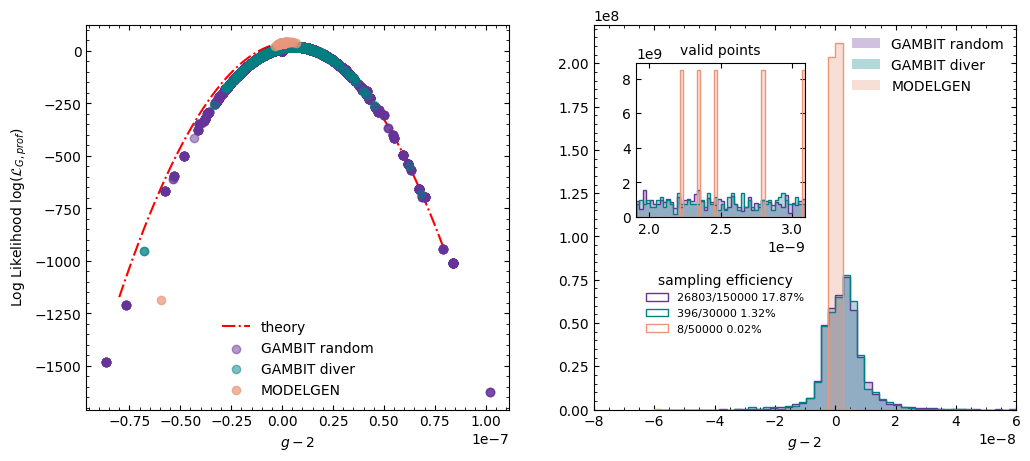

In [69]:
fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.linspace(-8e-8, 8e-8, 1000),  lnL_theory, linestyle='-.', color='red', zorder=0, label="theory")
ax1.scatter(gm2_gr, lnL_gm2_gr, color='rebeccapurple', marker='o', alpha=0.5, label="GAMBIT random")
ax1.scatter(gm2_gd, lnL_gm2_gd, color='teal', marker='o', alpha=0.5, label="GAMBIT diver")
ax1.scatter(gm2_mg, lnL_gm2_mg, color='darksalmon', marker='o', alpha=0.7, label="MODELGEN")
# ax1.set_xlim(-8e-8, 8e-8)

ax1.set_xlabel("$g - 2$")
ax1.set_ylabel("Log Likelihood $\\mathrm{log}(\\mathcal{L}_{G, prof})$")
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax1.legend(frameon=False)

ax2.hist(gm2_gr, bins=50, range=(-6e-8, 6e-8), density=True, histtype='stepfilled', alpha=0.3, facecolor='rebeccapurple', label=f"GAMBIT random")
ax2.hist(gm2_gd, bins=50, range=(-6e-8, 6e-8), density=True, histtype='stepfilled', alpha=0.3, facecolor='teal',          label=f"GAMBIT diver")
ax2.hist(gm2_mg, bins=50, range=(-6e-8, 6e-8), density=True, histtype='stepfilled', alpha=0.3, facecolor='darksalmon',    label=f"MODELGEN")
ax2.hist(gm2_gr, bins=50, range=(-6e-8, 6e-8), density=True, histtype='step', edgecolor='rebeccapurple')
ax2.hist(gm2_gd, bins=50, range=(-6e-8, 6e-8), density=True, histtype='step', edgecolor='teal')
ax2.hist(gm2_mg, bins=50, range=(-6e-8, 6e-8), density=True, histtype='step', edgecolor='darksalmon')
ax2.set_xlabel("$g - 2$")
ax2.minorticks_on()
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax2.set_xlim(-8e-8, 6e-8)
ax2.legend(frameon=False)

ax3 = ax2.inset_axes([0.1, 0.5, 0.4, 0.4], transform=ax2.transAxes)
ax3.hist(acc_points_gr, bins=50, range=acceptance_range, density=True, histtype='stepfilled', alpha=0.3, facecolor='rebeccapurple')
ax3.hist(acc_points_gd, bins=50, range=acceptance_range, density=True, histtype='stepfilled', alpha=0.3, facecolor='teal')
ax3.hist(acc_points_mg, bins=50, range=acceptance_range, density=True, histtype='stepfilled', alpha=0.3, facecolor='darksalmon')
ax3.hist(acc_points_gr, bins=50, range=acceptance_range, density=True, histtype='step', edgecolor='rebeccapurple', label=f"{len(acc_points_gr)}/{len(scan_gambit_random["LogLike"][:])} {round(eff_gr, 2)}%")
ax3.hist(acc_points_gd, bins=50, range=acceptance_range, density=True, histtype='step', edgecolor='teal', label=f"{len(acc_points_gd)}/{len(scan_gambit_diver["LogLike"][:])} {round(eff_gd, 2)}%")
ax3.hist(acc_points_mg, bins=50, range=acceptance_range, density=True, histtype='step', edgecolor='darksalmon', label=f"{len(acc_points_mg)}/{len(scan_modelgen["GM2_gmuon"][:])} {round(eff_mg, 2)}%")
ax3.set_xlim(acceptance_range[0], acceptance_range[1])
ax3.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax3.set_title("valid points", fontsize=10)
ax3.legend(frameon=False, fontsize=8, title="sampling efficiency", bbox_to_anchor=(0., -0.3), loc='upper left')






plt.show()